# Catalog Conversion of M1

In [46]:
# Standard libraries for data handling and analysis
import h5py  # For reading HDF5 data files
import numpy as np  # Numerical operations
import glob  # File pattern matching
import json  # JSON file handling
import os
import matplotlib.pyplot as plt  # Plotting
import matplotlib.cm as cm  # Colormaps
from matplotlib.colors import Normalize
from few.utils.constants import *
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies, get_separatrix

# Custom cosmology utilities (from common.py)
from common import CosmoInt  # Cosmology interpolator for distance-redshift conversions
from common import ref_cosmo  # Reference cosmology (FlatLambdaCDM)
from waveform_utils import *

# Configure matplotlib for publication-quality plots
plt.rcParams.update({'font.size': 18})
# plt.rcParams['figure.figsize'] = (16, 9)  # Double-column paper width
repo = "M1_catalog_cosmo/"
os.makedirs(repo, exist_ok=True)

# Cosmology: Redshift to Luminosity Distance

This section verifies the cosmology model by plotting the relationship between redshift *z* and luminosity distance *Dₗ*. The `CosmoInt` utility provides fast interpolated conversions between these quantities using the Planck 2018 cosmological parameters.

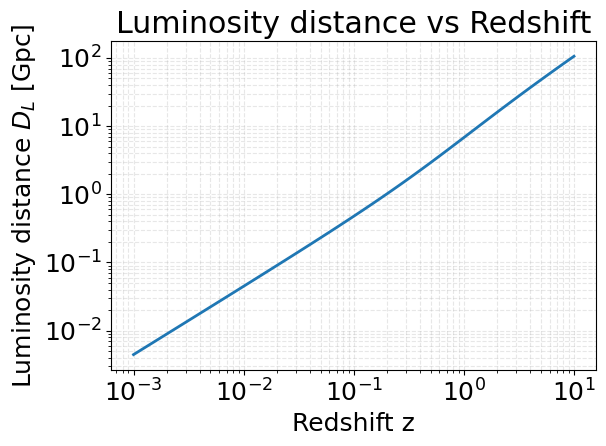

Distance at z = 0.01: 0.0446 Gpc


In [47]:
# Create redshift array spanning z = 0.001 to z = 10
z_vec = np.logspace(-3, 1, 100)

# Convert to luminosity distances (in Gpc)
d_vec = CosmoInt.get_luminosity_distance(z_vec)

# Plot redshift-distance relation
plt.figure()
plt.plot(z_vec, d_vec, linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Redshift z')
plt.ylabel(r'Luminosity distance $D_L$ [Gpc]')
plt.title('Luminosity distance vs Redshift')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Example: Get distance at z = 0.01
print(f"Distance at z = 0.01: {CosmoInt.get_luminosity_distance(1e-2):.4f} Gpc")

# Conversion of M1

In [48]:

labels = ["tPlunge",  "logmu",  "logM",  "ePlunge",  "nuPlunge",  "gamPlunge",  "phiPlunge",  "costhetaSky",  "phiSky",  "cosLambda",  "alpPlunge",  "SMBHspin",  "costhetaSpin",  "phiSpin",  "Zeta",  "SMBHQuad",  "SNR_tot",  "dist"]
M1_cat = np.loadtxt("EMRIcosmo_M1.txt", skiprows=1)
M1_cat.shape, len(labels)

((12, 18), 18)

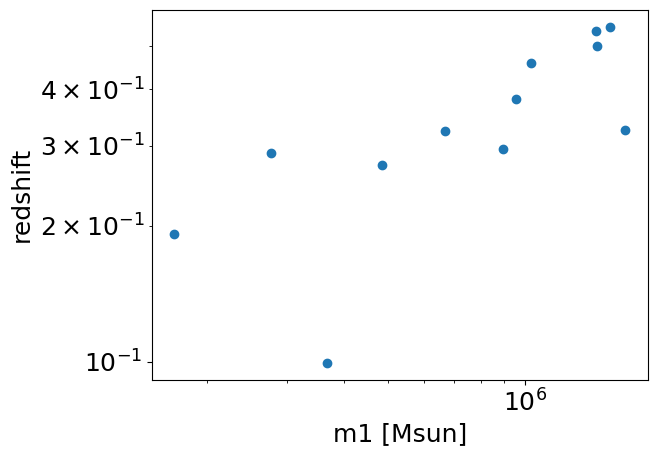

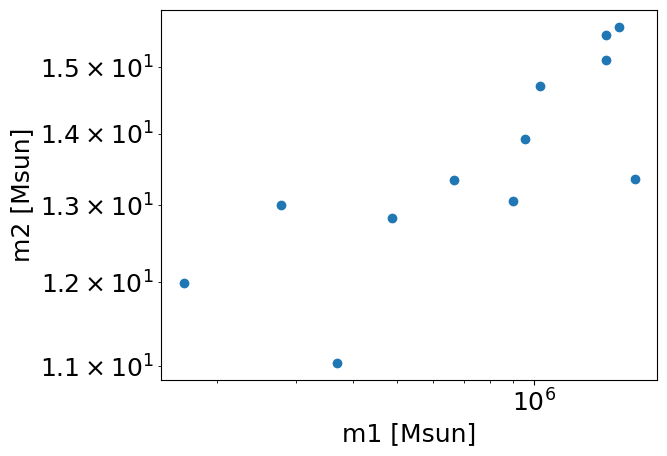

In [49]:
MTsun_fom = 4.9254909491978065e-06
PARSEC_METER_fom = 3.085677581491367e+16
light = 299792458.0
m1_list = np.exp(M1_cat[:, labels.index("logM")])/MTsun_fom
m2_list = np.exp(M1_cat[:, labels.index("logmu")])/MTsun_fom
DL = M1_cat[:, labels.index("dist")] # Gpc
redshift = CosmoInt.get_redshift(DL)
ef = M1_cat[:, labels.index("ePlunge")]
spin = M1_cat[:, labels.index("SMBHspin")]
Tpl_list = M1_cat[:, labels.index("tPlunge")] / YRSID_SI
thS = np.arccos(M1_cat[:, labels.index("costhetaSky")])
phS = M1_cat[:, labels.index("phiSky")]
thK = np.arccos(M1_cat[:, labels.index("costhetaSpin")])
phK = M1_cat[:, labels.index("phiSpin")]

plt.figure()
plt.loglog(m1_list, redshift, 'o')
plt.xlabel("m1 [Msun]")
plt.ylabel("redshift")
plt.show()

plt.figure()
plt.loglog(m1_list, m2_list, 'o')
plt.xlabel("m1 [Msun]")
plt.ylabel("m2 [Msun]")
plt.show()

In [50]:

traj = EMRIInspiral(func=KerrEccEqFluxPowerLaw)

M1_traj_out = []

for i in range(len(m1_list)):
    print(f"Processing system {i+1}/{len(m1_list)}: m1={m1_list[i]:.2e} Msun, m2={m2_list[i]:.2e} Msun, z={redshift[i]:.3f}")
    M = m1_list[i]
    mu = m2_list[i]
    a = spin[i]
    e_f = ef[i]
    Tpl = Tpl_list[i]
    x0_f = 1.0
    A = 0.0
    nr = 10
    p_f = traj.func.min_p(e_f, x0_f, a)

    t_forward, p_forward, e_forward, x_forward, Phi_phi_forward, Phi_r_forward, Phi_theta_forward = traj(M, mu, a, p_f, e_f, x0_f, A, nr, dt=1e-5, T=100.0, integrate_backwards=False)
    t_back, p_back, e_back, x_back, Phi_phi_back, Phi_r_back, Phi_theta_back = traj(M, mu, a, p_forward[-1], e_forward[-1], x_forward[-1], A, nr, dt=1e-5, T=Tpl, integrate_backwards=True)
    t_plot, p_plot, e_plot, x_plot, Phi_phi_plot, Phi_r_plot, Phi_theta_plot = traj(M, mu, a, p_back[-1], e_back[-1], x_back[-1], A, nr, dt=1e-5, T=Tpl, integrate_backwards=False)

    omegaPhi, omegaTheta, omegaR = get_fundamental_frequencies(a, p_plot, e_plot, x_plot)
    dimension_factor = 2.0 * np.pi * M * MTSUN_SI
    omegaPhi = omegaPhi / dimension_factor
    frequency_gw_2phi = np.abs(2 * omegaPhi)  # Dominant GW frequency
    M1_traj_out.append([t_plot, p_plot, e_plot, x_plot, Phi_phi_plot, Phi_r_plot, Phi_theta_plot, frequency_gw_2phi])


Processing system 1/12: m1=1.67e+06 Msun, m2=1.34e+01 Msun, z=0.325
Processing system 2/12: m1=3.67e+05 Msun, m2=1.10e+01 Msun, z=0.099
Processing system 3/12: m1=9.57e+05 Msun, m2=1.39e+01 Msun, z=0.381
Processing system 4/12: m1=2.77e+05 Msun, m2=1.30e+01 Msun, z=0.290
Processing system 5/12: m1=1.44e+06 Msun, m2=1.55e+01 Msun, z=0.537
Processing system 6/12: m1=1.44e+06 Msun, m2=1.51e+01 Msun, z=0.498
Processing system 7/12: m1=6.67e+05 Msun, m2=1.33e+01 Msun, z=0.324
Processing system 8/12: m1=4.86e+05 Msun, m2=1.28e+01 Msun, z=0.273
Processing system 9/12: m1=1.54e+06 Msun, m2=1.56e+01 Msun, z=0.550
Processing system 10/12: m1=8.98e+05 Msun, m2=1.31e+01 Msun, z=0.295
Processing system 11/12: m1=1.03e+06 Msun, m2=1.47e+01 Msun, z=0.458
Processing system 12/12: m1=1.69e+05 Msun, m2=1.20e+01 Msun, z=0.191


/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_37416/651263598.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  col = plt.cm.get_cmap('viridis', len(M1_traj_out))


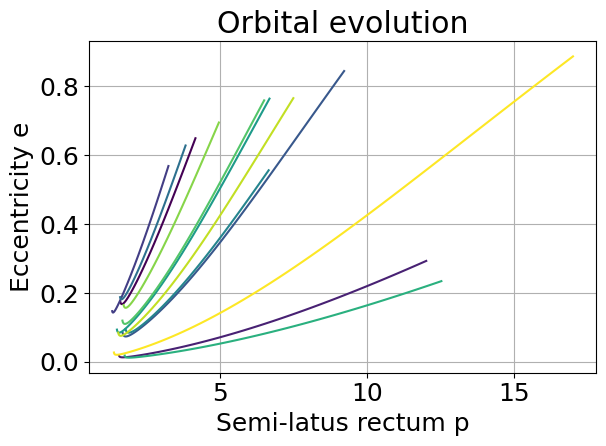

In [51]:
col = plt.cm.get_cmap('viridis', len(M1_traj_out))

plt.figure()
for ii,traj_elem in enumerate(M1_traj_out):
    t_plot, p_plot, e_plot, x_plot, Phi_phi_plot, Phi_r_plot, Phi_theta_plot, _ = traj_elem    
    plt.plot(p_plot, e_plot, color=col(ii), label=f"System {ii+1}")

plt.xlabel("Semi-latus rectum p")
plt.ylabel("Eccentricity e")
plt.title("Orbital evolution")
plt.grid()
plt.tight_layout()
plt.show()

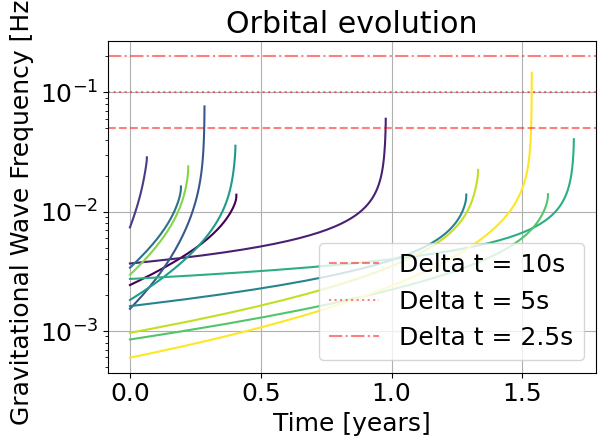

In [52]:
plt.figure()
for ii,traj_elem in enumerate(M1_traj_out):
    t_plot, p_plot, e_plot, x_plot, Phi_phi_plot, Phi_r_plot, Phi_theta_plot, fgw = traj_elem    
    plt.semilogy(t_plot / YRSID_SI, fgw, color=col(ii))#, label=f"System {ii+1}")
    # plt.axvline(Tpl_list[ii], color=col(ii), linestyle='--', alpha=0.5)
plt.axhline(1/(2*10.0), color='red', linestyle='--', alpha=0.5, label="Delta t = 10s")
plt.axhline(1/(2*5.0), color='red', linestyle=':', alpha=0.5, label="Delta t = 5s")
plt.axhline(1/(2*2.5), color='red', linestyle='-.', alpha=0.5, label="Delta t = 2.5s")
# plt.axhline(1/(2*0.5), color='red', linestyle='-', alpha=0.5, label="Delta t = 0.5s")

plt.legend()
plt.xlabel("Time [years]")
plt.ylabel("Gravitational Wave Frequency [Hz]")
plt.title("Orbital evolution")
plt.grid()
plt.tight_layout()
plt.show()

/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_37416/1026130438.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  col = plt.cm.get_cmap('viridis', len(M1_traj_out))


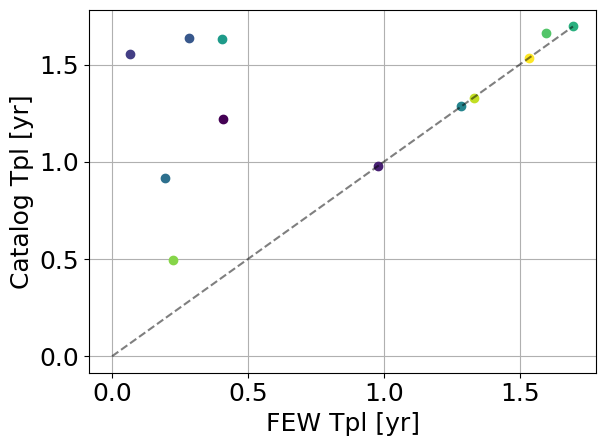

In [53]:
col = plt.cm.get_cmap('viridis', len(M1_traj_out))
plt.figure()
for ii,traj_elem in enumerate(M1_traj_out):
    t_plot, p_plot, e_plot, x_plot, Phi_phi_plot, Phi_r_plot, Phi_theta_plot, _ = traj_elem    
    plt.plot(t_plot[-1] / YRSID_SI, Tpl_list[ii], 'o', color=col(ii), label=f"System {ii+1}")
# plot diagonal line for reference
max_Tpl = max(Tpl_list)
plt.plot([0, max_Tpl], [0, max_Tpl], 'k--', alpha=0.5, label="y=x reference")
plt.xlabel("FEW Tpl [yr]")
plt.ylabel("Catalog Tpl [yr]")
plt.grid()
plt.tight_layout()
plt.show()

In [57]:
Tpl_few = t_plot[-1] / YRSID_SI
m1_src = m1_list * (1 + redshift)
m2_src = m2_list * (1 + redshift)
ef_src = ef
spin_src = spin
dt = 2.5

catalog = {}
for i in range(len(m1_list)):
    t_plot_i, p_plot_i, e_plot_i, x_plot_i, _, _, _, _ = M1_traj_out[i]
    Tpl_few_i = t_plot_i[-1] / YRSID_SI
    catalog[str(i)] = {
        "m1": m1_src[i],
        "m2": m2_src[i],
        "a": spin_src[i],
        "e_f": ef_src[i],
        "Tpl": Tpl_few_i,
        "dt": dt,
        "redshift": redshift[i],
    }
catalog
with open("M1_catalog.json", "w") as f:
    json.dump(catalog, f, indent=4, default=float)
